# RTM Phase 1c — Decision Stability under β Sensitivity (v1c)

This notebook compares **decision stability** across synthetic outcome scenarios where the
synthetic outcome generator coefficients (β_E, β_H) vary.

It **does not run inference**.
It expects inference idata files already produced (e.g. by `12_*` + your inference notebook).

## Expected inputs

For each scenario `<SCENARIO>`:

- Outcome (for metadata only):
  - `outputs/rtm/outcomes/Y_damage_v1c_<SCENARIO>.parquet`

- Inference posterior:
  - `outputs/rtm/inference/rtm_damage_v1c_<SCENARIO>_logistic_idata.nc`

## Outputs

- Summary table:
  - `outputs/rtm/decision_stability/v1c_beta/sensitivity_beta_summary.csv`
  - `outputs/rtm/decision_stability/v1c_beta/sensitivity_beta_summary.md`

- Figures:
  - `outputs/rtm/decision_stability/v1c_beta/figures/*`

In [1]:
from __future__ import annotations

from pathlib import Path
import sys
import re
import numpy as np
import pandas as pd
import arviz as az
import matplotlib.pyplot as plt

# --- Resolve repo root ---
REPO_ROOT = Path.cwd().resolve()
if REPO_ROOT.name.lower() == "notebooks":
    REPO_ROOT = REPO_ROOT.parent

assert (REPO_ROOT / "src").exists(), f"Not in resilient-housing-bayes repo: {REPO_ROOT}"

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

OUT_DIR = REPO_ROOT / "outputs" / "rtm" / "decision_stability" / "v1c_beta"
FIG_DIR = OUT_DIR / "figures"
OUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

OUTCOMES_DIR = REPO_ROOT / "outputs" / "rtm" / "outcomes"
INF_DIR = REPO_ROOT / "outputs" / "rtm" / "inference"

print("Repo:", REPO_ROOT)
print("Out :", OUT_DIR)
print("Outcomes dir:", OUTCOMES_DIR)
print("Inference dir:", INF_DIR)

Repo: C:\Users\C.Price\Habnetic\resilient-housing-bayes
Out : C:\Users\C.Price\Habnetic\resilient-housing-bayes\outputs\rtm\decision_stability\v1c_beta
Outcomes dir: C:\Users\C.Price\Habnetic\resilient-housing-bayes\outputs\rtm\outcomes
Inference dir: C:\Users\C.Price\Habnetic\resilient-housing-bayes\outputs\rtm\inference


In [2]:
# Discover scenarios from outcomes folder
# Expected: Y_damage_v1c_<SCENARIO>.parquet
pattern = re.compile(r"^Y_damage_v1c_(.+)\.parquet$")

scenario_files = []
scenarios = []

for p in sorted(OUTCOMES_DIR.glob("Y_damage_v1c_*.parquet")):
    m = pattern.match(p.name)
    if m:
        scenario = m.group(1)
        scenario_files.append(p)
        scenarios.append(scenario)

if not scenarios:
    raise FileNotFoundError(f"No v1c outcomes found in {OUTCOMES_DIR} matching Y_damage_v1c_*.parquet")

print("Found scenarios:")
for s in scenarios:
    print(" -", s)

# Set k values (must be <= N=5000 if your inference sample is 5000)
k_values = [1000, 2500, 5000]
print("k_values:", k_values)

Found scenarios:
 - bE02_bH06
 - bE10_bH02
 - bE10_bH06
k_values: [1000, 2500, 5000]


In [3]:
def bernoulli_entropy(p: np.ndarray, eps: float = 1e-12) -> np.ndarray:
    """Elementwise Bernoulli entropy for p in [0,1]."""
    p = np.clip(p, eps, 1 - eps)
    return -(p * np.log(p) + (1 - p) * np.log(1 - p))

def topk_membership_prob(p_samples: np.ndarray, k: int) -> np.ndarray:
    """
    Compute P(i in top-k) from posterior samples of p.
    p_samples: shape (S, N) where S = draws*chains
    returns: (N,)
    """
    S, N = p_samples.shape
    if k < 1 or k > N:
        raise ValueError(f"k must be in [1, N], got k={k}, N={N}")

    counts = np.zeros(N, dtype=np.int32)
    # argpartition for top-k indices, per draw
    for s in range(S):
        idx = np.argpartition(-p_samples[s], kth=k-1)[:k]
        counts[idx] += 1
    return counts / float(S)

def overlap_metrics(topA: np.ndarray, topB: np.ndarray) -> dict:
    """topA, topB are arrays of indices of length k."""
    A = set(map(int, topA))
    B = set(map(int, topB))
    inter = len(A.intersection(B))
    union = len(A.union(B))
    k = len(topA)
    return {
        "overlap_ratio": inter / k,
        "jaccard": inter / union if union else np.nan,
    }

In [4]:
rows = []

for scenario in scenarios:
    outcome_path = OUTCOMES_DIR / f"Y_damage_v1c_{scenario}.parquet"
    idata_path = INF_DIR / f"rtm_damage_v1c_{scenario}_logistic_idata.nc"

    if not idata_path.exists():
        print(f"[skip] Missing idata for {scenario}: {idata_path.name}")
        continue

    print(f"\n=== Scenario {scenario} ===")
    print("Outcome:", outcome_path.name, "(exists:", outcome_path.exists(), ")")
    print("Idata  :", idata_path.name)

    # Load outcome (for metadata only)
    meta = {}
    if outcome_path.exists():
        ydf = pd.read_parquet(outcome_path)
        # store what we can safely infer
        for col in ["outcome_version", "p0_baseline", "beta_E", "beta_H", "alpha", "seed"]:
            if col in ydf.columns:
                vals = ydf[col].unique()
                meta[col] = vals[0] if len(vals) else None

    # Load posterior
    idata = az.from_netcdf(idata_path)

    # posterior p is dims (chain, draw, obs_id)
    if "p" not in idata.posterior:
        raise KeyError(f"{idata_path.name} missing posterior variable 'p'")

    p = idata.posterior["p"]
    # stack chains/draws -> samples
    p_samples = p.stack(sample=("chain", "draw")).transpose("sample", "obs_id").values  # (S, N)
    S, N = p_samples.shape

    # deterministic ranking object: posterior mean p
    p_mean = p_samples.mean(axis=0)  # (N,)

    # compute once: ranking by p_mean
    rank_p_mean = np.argsort(-p_mean)

    for k in k_values:
        if k > N:
            print(f"[skip] k={k} > N={N} for scenario {scenario}")
            continue

        topk_prob = topk_membership_prob(p_samples, k=k)  # (N,)
        ent = bernoulli_entropy(topk_prob)

        # rank by topk_prob
        rank_topkprob = np.argsort(-topk_prob)

        topA = rank_p_mean[:k]
        topB = rank_topkprob[:k]
        ov = overlap_metrics(topA, topB)

        rows.append({
            "scenario": scenario,
            "k": k,
            "N": N,
            "S": S,
            "k_over_N": k / N,
            "mean_topk_prob": float(np.mean(topk_prob)),
            "share_topk_prob_gt_0_2": float(np.mean(topk_prob > 0.2)),
            "share_topk_prob_between_0_2_0_8": float(np.mean((topk_prob > 0.2) & (topk_prob < 0.8))),
            "entropy_mean": float(np.mean(ent)),
            "entropy_p95": float(np.quantile(ent, 0.95)),
            "overlap_ratio": ov["overlap_ratio"],
            "jaccard": ov["jaccard"],
            # meta if available
            **{f"meta_{kk}": vv for kk, vv in meta.items()},
            "idata_file": idata_path.name,
        })

summary = pd.DataFrame(rows).sort_values(["scenario", "k"]).reset_index(drop=True)
summary


=== Scenario bE02_bH06 ===
Outcome: Y_damage_v1c_bE02_bH06.parquet (exists: True )
Idata  : rtm_damage_v1c_bE02_bH06_logistic_idata.nc

=== Scenario bE10_bH02 ===
Outcome: Y_damage_v1c_bE10_bH02.parquet (exists: True )
Idata  : rtm_damage_v1c_bE10_bH02_logistic_idata.nc

=== Scenario bE10_bH06 ===
Outcome: Y_damage_v1c_bE10_bH06.parquet (exists: True )
Idata  : rtm_damage_v1c_bE10_bH06_logistic_idata.nc


,scenario,k,N,S,k_over_N,mean_topk_prob,share_topk_prob_gt_0_2,share_topk_prob_between_0_2_0_8,entropy_mean,entropy_p95,overlap_ratio,jaccard,meta_outcome_version,meta_p0_baseline,meta_beta_E,meta_beta_H,meta_alpha,meta_seed,idata_file
0,bE02_bH06,1000,5000,1000,0.2,0.2,0.2120,0.0242,2.553540e-02,1.712663e-01,0.9960,0.992032,v1c_bE02_bH06,0.05,0.2,0.6,-2.944439,42,rtm_damage_v1c_bE02_bH06_logistic_idata.nc
1,bE02_bH06,2500,5000,1000,0.5,0.5,0.5222,0.0442,5.108318e-02,4.622501e-01,0.9996,0.999200,v1c_bE02_bH06,0.05,0.2,0.6,-2.944439,42,rtm_damage_v1c_bE02_bH06_logistic_idata.nc
2,bE02_bH06,5000,5000,1000,1.0,1.0,1.0000,0.0000,2.863041e-11,2.863041e-11,1.0000,1.000000,v1c_bE02_bH06,0.05,0.2,0.6,-2.944439,42,rtm_damage_v1c_bE02_bH06_logistic_idata.nc
3,bE10_bH02,1000,5000,1000,0.2,0.2,0.2180,0.0360,3.932786e-02,3.649278e-01,0.9990,0.998002,v1c_bE10_bH02,0.05,1.0,0.2,-2.944439,42,rtm_damage_v1c_bE10_bH02_logistic_idata.nc
4,bE10_bH02,2500,5000,1000,0.5,0.5,0.5132,0.0266,3.201818e-02,2.405091e-01,0.9996,0.999200,v1c_bE10_bH02,0.05,1.0,0.2,-2.944439,42,rtm_damage_v1c_bE10_bH02_logistic_idata.nc
5,bE10_bH02,5000,5000,1000,1.0,1.0,1.0000,0.0000,2.863041e-11,2.863041e-11,1.0000,1.000000,v1c_bE10_bH02,0.05,1.0,0.2,-2.944439,42,rtm_damage_v1c_bE10_bH02_logistic_idata.nc
6,bE10_bH06,1000,5000,1000,0.2,0.2,0.2080,0.0158,1.737690e-02,4.170836e-02,0.9990,0.998002,v1c_bE10_bH06,0.05,1.0,0.6,-2.944439,42,rtm_damage_v1c_bE10_bH06_logistic_idata.nc
7,bE10_bH06,2500,5000,1000,0.5,0.5,0.5130,0.0256,2.593385e-02,1.711093e-01,0.9984,0.996805,v1c_bE10_bH06,0.05,1.0,0.6,-2.944439,42,rtm_damage_v1c_bE10_bH06_logistic_idata.nc
8,bE10_bH06,5000,5000,1000,1.0,1.0,1.0000,0.0000,2.863041e-11,2.863041e-11,1.0000,1.000000,v1c_bE10_bH06,0.05,1.0,0.6,-2.944439,42,rtm_damage_v1c_bE10_bH06_logistic_idata.nc


In [5]:
out_csv = OUT_DIR / "sensitivity_beta_summary.csv"
summary.to_csv(out_csv, index=False)
print("Saved:", out_csv)

def df_to_markdown_simple(df: pd.DataFrame) -> str:
    # Minimal markdown table writer. No dependencies.
    cols = list(df.columns)
    lines = []
    lines.append("| " + " | ".join(cols) + " |")
    lines.append("| " + " | ".join(["---"] * len(cols)) + " |")
    for _, r in df.iterrows():
        lines.append("| " + " | ".join(str(r[c]) for c in cols) + " |")
    return "\n".join(lines)

# Keep the md readable: only the key columns
md_cols = [
    "scenario","k","N","k_over_N",
    "overlap_ratio","jaccard",
    "share_topk_prob_between_0_2_0_8",
    "entropy_mean","entropy_p95",
    "meta_p0_baseline","meta_beta_E","meta_beta_H","meta_alpha",
]
md_view = summary[[c for c in md_cols if c in summary.columns]].copy()

out_md = OUT_DIR / "sensitivity_beta_summary.md"
out_md.write_text(df_to_markdown_simple(md_view), encoding="utf-8")
print("Saved:", out_md)

Saved: C:\Users\C.Price\Habnetic\resilient-housing-bayes\outputs\rtm\decision_stability\v1c_beta\sensitivity_beta_summary.csv
Saved: C:\Users\C.Price\Habnetic\resilient-housing-bayes\outputs\rtm\decision_stability\v1c_beta\sensitivity_beta_summary.md


In [6]:
# Average across k (excluding k=N where borderline is always 0 and overlap is trivially 1)
tmp = summary.copy()
tmp = tmp[tmp["k"] < tmp["N"]]

agg = tmp.groupby("scenario")[["overlap_ratio","share_topk_prob_between_0_2_0_8","entropy_mean"]].mean()
print(agg.sort_values("share_topk_prob_between_0_2_0_8", ascending=False))

           overlap_ratio  share_topk_prob_between_0_2_0_8  entropy_mean
scenario                                                               
bE02_bH06         0.9978                           0.0342      0.038309
bE10_bH02         0.9993                           0.0313      0.035673
bE10_bH06         0.9987                           0.0207      0.021655


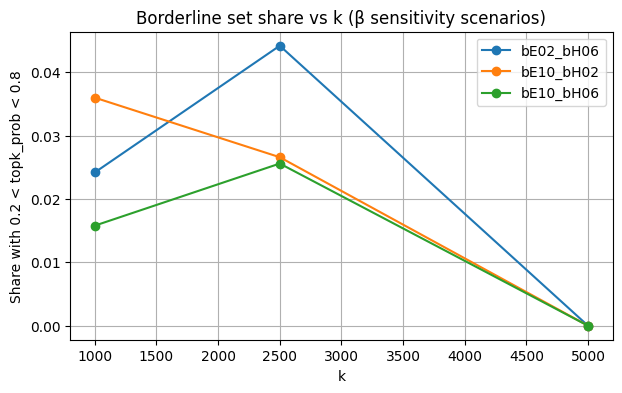

Saved: C:\Users\C.Price\Habnetic\resilient-housing-bayes\outputs\rtm\decision_stability\v1c_beta\figures\borderline_share_vs_k_by_scenario.png


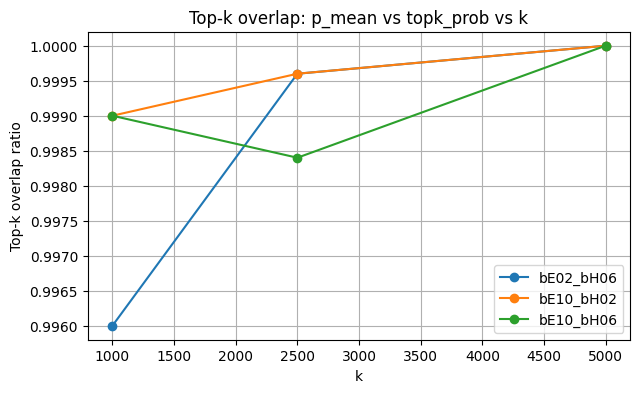

Saved: C:\Users\C.Price\Habnetic\resilient-housing-bayes\outputs\rtm\decision_stability\v1c_beta\figures\overlap_ratio_vs_k_by_scenario.png


In [7]:
# Plot borderline share vs k for each scenario
plt.figure(figsize=(7,4))
for scenario, g in summary.groupby("scenario"):
    plt.plot(g["k"], g["share_topk_prob_between_0_2_0_8"], marker="o", label=scenario)
plt.xlabel("k")
plt.ylabel("Share with 0.2 < topk_prob < 0.8")
plt.title("Borderline set share vs k (β sensitivity scenarios)")
plt.grid(True)
plt.legend()
fig_path = FIG_DIR / "borderline_share_vs_k_by_scenario.png"
plt.savefig(fig_path, dpi=160, bbox_inches="tight")
plt.show()
print("Saved:", fig_path)

# Plot overlap ratio vs k for each scenario
plt.figure(figsize=(7,4))
for scenario, g in summary.groupby("scenario"):
    plt.plot(g["k"], g["overlap_ratio"], marker="o", label=scenario)
plt.xlabel("k")
plt.ylabel("Top-k overlap ratio")
plt.title("Top-k overlap: p_mean vs topk_prob vs k")
plt.grid(True)
plt.legend()
fig_path = FIG_DIR / "overlap_ratio_vs_k_by_scenario.png"
plt.savefig(fig_path, dpi=160, bbox_inches="tight")
plt.show()
print("Saved:", fig_path)